<a href="https://colab.research.google.com/github/TienNguyen0712/ai-engineer-journey/blob/main/chapter2_pytorch_neural_network_classification/chapter2_pytorch_neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bài toán phân loại là gì?**

Bài toán phân loại thực hiện việc dự đoán một điều gì đó là cái này hoặc cái khác:

Các kiểu bài toán phân loại bao gồm:

- **Phân loại nhị phân:** Dự đoán xem đối tượng sẽ là 1 trong 2 lựa chọn (Có hoặc không) *Ví dụ: Dự đoán xem một người có bị bệnh tim mạch hay không dựa theo các thông tin sức khỏe của họ?*
- **Phân loại nhiều lớp:** Dự đoán xem đổi tượng sẽ thuộc 1 hay nhiều hơn lựa chọn *Ví dụ: Lựa chọn xem một tấm ảnh có thể là về đồ ăn, con người hoặc động vật*
- **Phân loại nhiều nhãn:**  Dự đoán xem có thể đối tượng được gán nhiều hơn 1 nhãn *Ví dụ: Dự đoán phân loại của các chủ dể trên Wikipeida*

Phân loại cùng với tuyến tính là 1 trong hai bài toán ohoor biến nhất trong học máy

## **0. Kỹ thuật của mạng nơ ron phân loại**

Các tham số cần lưu ý trong kỹ thuật phân loại với mạng nơ ron:
- **Input layer shape (`in_feature`):**  
  - **Phân loại nhị phân:** Giống với các đặc trưng số (giới tinh, cân nặng, tuổi, chiều cao, khả năng dự đoán bị tim mạch hay không, ... )
  - **Phân loại đa lớp:** Giống với phân loại nhị phân
- **Hidden layer(s)**
    - **Phân loại nhị phân:** Các layer phân tích vấn đề, bé nhất là 1 lớp và không giới hạn lớp
  - **Phân loại đa lớp:** Giống với phân loại nhị phân
- **Neurons per hidden layer (Nơ ron trong mỗi hàm ẩn)**
  - **Phân loại nhị phân:** Các nơ ron trong các lớp bé nhất là 10 đến 512
  - **Phân loại đa lớp:** Giống với phân loại nhị phân
- **Output layer shape (`out_features`)**
  - **Phân loại nhị phân:** 1 (1 lớp hoặc còn lại)
  - **Phân loại đa lớp:** 1 hoặc nhiều (ví dụ: 3 được gắn nhãn cho đồ ăn, 1 người hoặc ảnh động vật)
- **Hidden layer activation (Lớp kích hoạt)**
  - **Phân loại nhị phân:** Thông thường sử dụng hàm ReLu (gần với tuyến itnhs) hoặc có thể là nhiều hàm khác
  - **Phân loại đa lớp:** Giống với phân loại nhị phân
- **Output activation**
  - **Phân loại nhị phân:** Hàm sigmoid (`torch.sigmoid` trong PyTorch)
  - **Phân loại đa lớp:** Hàm Softmax (`torch.softmax` trong PyTorch)
- **Loss function**
  - **Phân loại nhị phân:** Binary crossentropy (`torch.nn.BCELoss`)
  - **Phân loại đa lớp:** Cross entropy (`torch.nn.CrossEntropyLoss`)
- **Optimizer**
  - **Phân loại nhị phân:** SGD hoặc Adam với nhiều lựa chọn khác
  - **Phân loại đa lớp:** Giống với phân loại nhị phân


Xem thêm: https://en.wikipedia.org/wiki/Activation_function#Table_of_activation_functions (Hàm kích hoạt khác)
- Cross entropy: https://en.wikipedia.org/wiki/Cross-entropy#Cross-entropy_loss_function_and_logistic_regression
- Binary crossentropy: https://docs.pytorch.org/docs/2.11/generated/torch.nn.CrossEntropyLoss.html
- ReLU: https://docs.pytorch.org/docs/2.11/generated/torch.nn.ReLU.html#torch.nn.ReLU
- Sigmoid: https://en.wikipedia.org/wiki/Sigmoid_function
- Softmax: https://en.wikipedia.org/wiki/Softmax_function
- SGD: https://docs.pytorch.org/docs/2.11/generated/torch.optim.SGD.html
- Adam:https://docs.pytorch.org/docs/2.11/generated/torch.optim.Adam.html



## **1. Tạo dữ liệu để huấn luyện**


In [1]:
from sklearn.datasets import make_circles


# Tạo 1000 mẫu
n_samples = 1000

# Tạo hình tròn
X, y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values

In [2]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [3]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


`x1` và `x2` ta sẽ xem như là những đặc trưng những giá trị đầu vào để huấn luyện cho ra những `label`. Đây chính lầ **phân loại nhị phân** khi chỉ có 2 nhãn (1 hoặc 0)


In [4]:
# Kiểm tra xem có bao nhiêu nhãn khác nhau
circles["label"].value_counts()

,count
label,
1,500
0,500


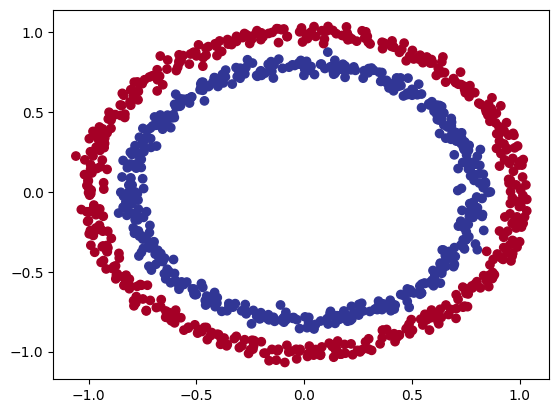

In [5]:
# Trực quan hóa nhãn
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

Bây giờ nhiệm vụ của ta là làm sao để xây dựng một mô hình nơ ron để có thể phân loại một dấu chấm thành red (0) hoặc xanh (1)

### **Hình dạng của dữ liệu đầu vào và đầu ra**

Một trong những lỗi sai phổ biến của học sâu chính là sai kích thước `shape`. Khi thực hiện sai kích thước với tensors sẽ cho ra kết quả sau với moohinfh.

In [6]:
# Kiểm tra shape của features và labels
print(f"X Tensor: {X.shape}")
print(f"y Tensor: {y.shape}")

X Tensor: (1000, 2)
y Tensor: (1000,)


In [7]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


Cho ta biết rằng chiều thứ hai của `x` chính là hai đặc trưng `features` nhìn sang với `y` chỉ là một `scalar` - số vô hướng

**Tóm lại:** Ta có 2 inputs và 1 output

### **Chuyển dữ liệu thành tensors và tạo train và test**

Các bước để chuẩn bị dữ liệu bao gồm:
- Chuyền dữ liệu thành tensors (Bây giờ dữ liệu của ta là Numpy Array và dễ dàng hơn với PyTorch khi sử dụng tensor)
- Chia duex liệu thành ập train và tập test để học pattern giữa các biến `X` và `y` và sau đó đánh giá được những pattern đó tối như thế nào qua tập test

In [8]:
# Chuyển data thành tensor
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Xem 5 mẫu đầu tiên
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
# Chia tập train và test dùng 80% train và 20% test
from sklearn.model_selection import train_test_split # Dùng thư viện để chia

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## **2. Xây dựng mô hình**

Khi ta đã có dữ liệu bước tiếp theo chính là xây dựng mô hình. Ta sẽ chia việc huấn luyện mô hình thành nhiều bước:
- Cài đặt thiết bị sử dụng để chạy code (CPU hoặc GPU nếu có thể)
- Dựng mô hình là subclass của `nn.Module`
- Định nghĩa hàm loss và tối ưu
- Xây dựng vòng lặp huấn luyện


In [10]:
# Nạp thư viện torch
import torch
from torch import nn

# Chuyển trình chạy code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Bây giờ `device` đã được cài đặt hoàn chỉnh  với tất cả dữ liệu hoặc mô hình chúng ta tạo và PyTorch sẽ măc định là chạy CPU hoặc GPU nếu có thể

Về vấn đề tạo mô hình ta sẽ quan tâm tới làm sao để mô hình chuyển từ `X` với vai trò là đầu vào làm sao trở về đúng hình dạng với `y`. Hay nói cách khác chính là là sao để dự đoán được `y` khi đã có `x`

Đây được gọi là bài toán học có giám sát (dựa theo dữ liệu đã cung cấp). Bởi vị dữ liệu huấn luyện đã cho biết tước nhãn là gì. Để tạo mô hình ta cần đầu vào `x` và đầu ra `y`

Các bước để tạo mô hình gồm
- Subclass `nn.Module`
- Tạo 2 hàm tuyên tính `nn.Linear` là lớp để thực hiện biến đổi với input `x` sao cho khớp với hình dạng của output `y`
- Định nghĩa làm `foward()` hằm tính toán trong mô hình
- Tạo nhánh mới và khai bao các tham số  

In [11]:
# Tạo subclass nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # Tạo 2 layer là 2 hàm tuyến tính nhằm biến đổi hình dạng x và y sao cho khớp nhau
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # Lây 2 đặc trưng (x) sinh 5 đặc trưng
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # Lây 5 features biến đổi thành 1 đặc trưng (y)
        # Dựng phương thức forward
    def forward(self, x):
        # Trả về giá trị tron layer_2 chung hình dạng với y
        return self.layer_2(self.layer_1(x)) # Đặc trưng sẽ đi từ layer_1 rồi out layer_1 sẽ đến layer_2
# Tạo nhánh và thực hiện truyền device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

Ta sẽ quan sát giữa hai hàm `self.layer_1` và `self.layer_2` đồi với hàm layer thứ 1 nó sẽ lấy 2 đặc trưng đầu vào và biến đổi thành 5 đầu ra. Như ta đã biết số 5 ở đây chính là **5 đơn vị hidden** hay **5 nơ ron**. Tại sao lại làm điều này

Bởi vì khi chia thành 5 số mô hình sẽ có khả năng học tốt hơn khi chia chỉ có 2 đặc trưng

Các con só dược sử dụng cho các lớp nơ ron ta gọi là một siêu tham số **(hyperparameter )** một giá trị mà ta có thể tự mình dặt. Tùy nhiên ta có thể cài dặt các siêu tham số này nhiều hơn hoặc ít hơn nhưng tùy trường hợp và các loại dữ liệu ta làm việc mà nên cân nhắc lựa chọn

Một số lưu ý nhỏ trong đơn vị cúa lớp tiếp theo `in-features` sẽ phải trùng với  `out-features` của lớp trước đó - Đó cũng là vì sao `layer_2` có in là 5 để trùng với out của `layer_1` và cuối cùng phải trả về 1 chính là shape của output sau cùng

Xem thêm: https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.02111&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false

Ta cũng có thể làm tương tự code trên sử dụng `nn.Sequential`. Với hàm này ta sẽ truyền luôn hàm forward làm dữ liệu thông qua các lớp theo thứ tự trên xuống  

In [12]:
# Viết lại theo nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2,
              out_features=5),
    nn.Linear(in_features=5,
              out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.1787],
        [-0.2570],
        [ 0.0083],
        [-0.2316],
        [-0.0210],
        [-0.0686],
        [-0.2661],
        [-0.2220],
        [ 0.0093],
        [-0.2626]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


Xem như kết quả dự đoán không giống với tập testing do đó ta sẽ sửa

### **Cài đặt hàm loss và tối ưu hóa**

Tùy loại bài toán khác nhau mà ta sẽ lựa chọn các hàm loss khác nhau:

Đối với bài toàn phân loại ta sẽ sử dụng hàm [binary cross entropy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a/) Và lựa chọn mô hình hóa cũng có thể lựa chọn chung giữa các bài toán khác nhau:

Các hàm loss/tối ưu thường thấy:
- **Stochastic Gradient Descent (SGD) optimizer**: Dùng cho phân loại tuyến tính và nhiều thứ khác (`torch.optim.SGD()`)
- **Adam Optimizer**:  Dùng cho phân loại tuyến tính và nhiều thứ khác (`torch.optim.Adam()`)
- **Binary cross entropy loss:** Phân loại nhị phân (`torch.nn.BCELossWithLogits` or `torch.nn.BCELoss`)
- **Cross entropy loss: **Phân loại nhiều nhãn (`torch.nn.CrossEntropyLoss`)
- **Mean absolute error (MAE) or L1 Loss:** Tuyến tính (`torch.nn.L1Loss`)
- **Mean squared error (MSE) or L2 Loss:** Tuyến tính (`torch.nn.MSELoss`)

Ghi nhớ rằng: Hàm loss thể hiện dự đoán sai với thực tế bao nhiêu, loss càng tăng học càng sai

In [14]:
# Dựng hàm loss
# loss_fn = nn.BCELoss() # BCELoss = không sigmoid
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Tạo tối ưu hóa
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

PyTorch thường sẽ có 2 cách binary cross entropy
- `torch.nn.BCELoss()` tạo loss biểu diễn cho việc target và đầu vào đặc trưng
- `torch.nn.BCEWithLogitsLoss()` không khác gì cái trên nhưng có Sigmoid hàm (sẽ ổn định tham số hơn hàm trên sau khi có thêm hàm Sigmoid)

Do đo sử dụng hàm thứ 2 là tối ưu. Tuy nhiên ta cũng có thể so sánh cả hai để tìm ra cái nào tốt nhất

Xem thêm: https://discuss.pytorch.org/t/bceloss-vs-bcewithlogitsloss/33586/4



Tạo metric đánh giá mô hình. việc dánh giá và sử dụng luôn những metric khác dang đi đúng hướng hay không

Nếu hàm loss chỉ cho biết mô hình sai như thế nào thì các metric lại cho các dánh giá hoàn toàn khác. Đánh giá sử dụng metric giúp ta hìn kết quả dữ liệu dự đoán nhiều chiều góc nhìn khác nhau

Có nhiều metric nhưng đầu tiên có thể là `Accuracy` biểu diễn chia tổng só lượng dự đoán đúng cho tổng các số lượng dự đoán *(Ví dụ: Mô hình dự đáon đúng 99 trong tổng số 100 dự đoán thì nó đạt accuracy là 99%)*

In [15]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

## **3. Huấn luyện mô hình**

Nhắc lại về các bước training loop

- **Forward pass:** Mô hình sẽ đưa tất cả các dữ liệu trong tập train một lần qua các phép tính biểu diễn trong hàm `forward()`
- **Tính toán hàm loss:** So sánh xem dữ liệu đầu ra của dự đoán sẽ khác so với dữ liệu thực tế bao nhiêu `loss = loss_fn(y_pred, y_train)`
- **Zero gradient:** Ta dặt các tham số tối ưu gradient về 0 (để có thể tính toán lại hàm gradient qua từng lớp training khác) `optimizer.zero_grad()`
- **Thực hiện lan truyền ngược (backpropagation) trên loss:** Thực hiện tính toán gradient của hàm loss có được thông qua việc các tham số được cập nhật, duy trì từ output -> layer_3 -> layer_2 -> ... -> lớp input (cập nhật gradient thông qua `requires_grad=True`)
- **Thực hiện tối ưu hóa (gradient descent):** Cập nhật tham số với hàm `requires_grad=True` thông qua các thuật toán tối ưu để cải thiện gradient

### **Thực hiện từ đầu ra của mô hình đến nhãn được dữ đoán (logits -> dự đáon xác suất -> nhãn được dự đoán)**

Trước khi thực hiện bước tạo vòng lặp training, hãy xem mô hình thực sự làm gì trong suốt quá trình đi qua hàm forward (`foward()`)

Để thực hiện được việc này hãy xem qua dữ liệu ra của mô hình


In [17]:
# Xem qua 5 dữ liệu đầu ra khi qua hàm forward trên tập dữ liệu testing
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.1787],
        [-0.2570],
        [ 0.0083],
        [-0.2316],
        [-0.0210]], device='cuda:0', grad_fn=<SliceBackward0>)

Được biết mô hình của ta chưa dược huấn luyện mà các dữ liệu đầu ra này chỉ là ngẫu nhiên, nhưng chúng là gì -> Chính là những đầu ra khi qua hàm `forward()` trong class của chúng ta. Với theo công ghức của hàm tuyến tính `nn.Linear()`

$$\mathbf{y} = x \cdot \mathbf{Weights}^T + \mathbf{bias}$$

Dữ liệu ban đầu chưa dược điều chỉnh *(raw)* trong hàm trên chính là $y$ và dữ liệu ban đầu trong mô hình của ta thường được gọi là [logits](https://datascience.stackexchange.com/questions/31041/what-does-logits-in-machine-learning-mean/31045#31045)

Để có thể lấy dữ liệu đầu ra (raw) theo một quy luật nào đó ta sử dụng hàm kích hoạt **sigmoid**

In [18]:
# Dùng hàm sigmoid cho logits của mô hình
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4555],
        [0.4361],
        [0.5021],
        [0.4424],
        [0.4947]], device='cuda:0', grad_fn=<SigmoidBackward0>)

Sau khi thêm hàm **sigmoid** xem như hàm của ta đã có quy luật tuy nhiên chúng vẫn đang là giá trị ngẫu nhiên, ngay bây giờ sau khi đã đi qua hàm **sigmoid** chúng được xem là **giá trị dự đoán xác suất (prediction probabilities)** (thường biểu diễn với biên `y_pred_probs`), nói cách khác chính là gí trị mà mô hình nghĩ với mỗi nhãn chúng đúng lầ bao nhiêu

*Ví dụ:*
Trong trường hợp phân loại nhị phân (nhãn 0 hoặc 1):
- Nếu `y_pred_probs` >= 0.5, y = 1 (lớp 1)
- Nếu `y_pred_probs` < 0.5, y = 0 (lớp 0)

Để cso thể chuyển các xác suất dự đoán thành nhãn ta có thể làm tròn dựa theo đầu ra của hàm kích hoạt sigmoid

In [20]:
# Tím nhãn dự đoán (làm tròn xác suất dự đoán)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Kiểm tra chiều của dự đoán có bằng với nhãn thực tế hay không
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Thêm 1 chiều cho dữ liệu
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 0.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [21]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

Ta sẽ sử dụng đầu ra dự đoán của mô hình để so sánh vơi nhãn test để biết hiệu suất mô hình như thế nào. Tóm lại ta vừa thực hiện việc chuyển các dữ liệu ban đầu (raw) từ dữ liệu đầu vào khi đi qua hàm `forward()` qua hàm kích hoạt `sigmoid` làm tròn và chuyển chúng thành nhãn dự đoán

> Lưu ysL Sử dụng hàm kích hoạt sigmoid chỉ cho logits nhị phân. Cho nhiều lớp sử dụng hàm softmax. Và hàm sigmoid cần thiết đối với các đầu ra trong hàm `nn.BCEWithLogitsLoss`

### **Xây dựng training loop và Testing loop**

Thực hiện training thông qua 100 epochs và dầu ra của mô hình sẽ tiến triên thông qua 10 epochs

In [22]:
torch.manual_seed(42)

# Cài đặt số lượng epochs
epochs = 100

# Đặt dữ liệu về chung một device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Dựng training loop và testing loop
for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train).squeeze() # squeeze to remove extra `1` dimensions, this won't work unless model and data are on same device
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labls

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train)
    loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69711, Accuracy: 46.38% | Test loss: 0.69215, Test acc: 50.50%
Epoch: 10 | Loss: 0.69599, Accuracy: 47.50% | Test loss: 0.69140, Test acc: 52.00%
Epoch: 20 | Loss: 0.69538, Accuracy: 47.75% | Test loss: 0.69119, Test acc: 54.00%
Epoch: 30 | Loss: 0.69497, Accuracy: 48.12% | Test loss: 0.69120, Test acc: 53.00%
Epoch: 40 | Loss: 0.69467, Accuracy: 48.62% | Test loss: 0.69129, Test acc: 54.00%
Epoch: 50 | Loss: 0.69442, Accuracy: 48.50% | Test loss: 0.69142, Test acc: 53.00%
Epoch: 60 | Loss: 0.69423, Accuracy: 47.62% | Test loss: 0.69157, Test acc: 53.00%
Epoch: 70 | Loss: 0.69406, Accuracy: 48.50% | Test loss: 0.69173, Test acc: 50.50%
Epoch: 80 | Loss: 0.69392, Accuracy: 48.38% | Test loss: 0.69189, Test acc: 51.00%
Epoch: 90 | Loss: 0.69381, Accuracy: 48.38% | Test loss: 0.69205, Test acc: 51.50%


Độ chính xác `Accuracy` nằm quanh quẩn trong khoảng 50% điều này cho thấy ta dã làm việc với bộ dữ liệu nhị phân cân bằng, cho rằng mô hình của ta có hiệu suất tốt và dự đoán ngẫu nhiên (Với 500 mãu nhãn 0 và 1 mô hình dự doán nhãn 1 mối lần 50%)

## **4. Thực hiện dự đoán và đánh giá mô hình**

Theo phần trên xem như mô hình đang dự đáon ngẫu nhiên. Thực hiện việc trực quan dự đoán của mô hình

In [23]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


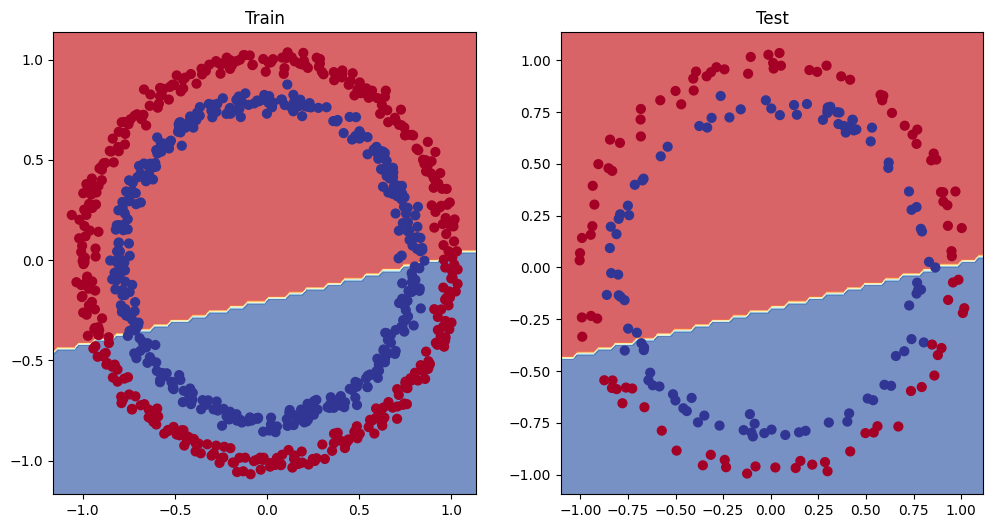

In [24]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

Khi đã trực quan hóa đầu ra của dữ liệu ta nhận thấy rằng mô hình đang có tình chia thành các dấu chấm sử dụng 1 đường thẳng, điều này cũng giải thích rằng tại sao lại có 50% độ chính xác. Với dữ liệu là đương tròn khong gì tốt hơn là chia thành giữa. Trong học máy mô hình của ta dược xem là **underfitting** khi mà mô hình không học bất cứ patterns từ dữ liệu của ta. Vậy làm sao để cải thiện nó

## **5. Cải thiện mô hình (từ các vấn đề mô hình)**

Ta sẽ tập trung vào việc cải thiện các vấn đề của mô hình (không dữ liệu). Ta có thể thực hiện một số cách:
- **Thêm lớp:** Mỗi lớp có khả năng cải thiện độ sâu, độ rộng của mô hình với mỗi lớp đó có thể học được các đặc trưng pattern mới trong dữ liệu. Nhiều lớp hơn sẽ làm cho mạng neuron của ta sâu hơn
- **Thêm dơn vị hàm ẩn (hidden units):** Giống với trên nhiều đơn vị trong mỗi lớp sẽ đồng nghĩa vởi khả năng gia tăng khả năng học của mô hình. Nhiều đơn vị hidden sexlafm cho mô hình rộng hơn
- **Fit lâu hơn (Thêm epochs):** Mô hình nên học lâu hơn qua mỗi lần huấn lyện thay vì chỉ nhìn thoáng qua
- **Thay đổi hàm kích hoạt:** Nhiều dữ liệu không thể fit với phương trình đường thẳng, sử dụng các hàm phi tuyên tính đẻ gia tăng khả năng học của mô hình
- ****
- ****
- ****